In [2]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from imblearn.over_sampling import SMOTE

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

import joblib

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv(
    r"C:\Users\abera\Downloads\featured_telco_churn.csv"
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Tenure_Group,TotalCharges_Group,MonthlyCharges_Group,Avg_Monthly_Spend,Customer_Lifetime_Value,Has_Internet,Has_Security,Streaming_User,Support_User,Service_Count
0,0,0,1,0,0.013889,0,1,0,0,2,...,0-12,Low,Low,0.052298,0.003491,0,0,0,0,0.142857
1,1,0,0,0,0.472222,1,0,0,2,0,...,25-48,Low,Medium,0.408086,0.226468,0,1,0,1,0.285714
2,1,0,0,0,0.027778,1,0,0,2,2,...,0-12,Low,Medium,0.244717,0.012596,0,1,0,0,0.285714
3,1,0,0,0,0.625000,0,1,0,2,0,...,25-48,Low,Low,0.280845,0.222632,0,1,0,1,0.428571
4,0,0,0,0,0.027778,1,0,1,0,0,...,0-12,Low,Medium,0.376792,0.016538,1,0,0,0,0.000000


In [3]:
print(df.shape)

df.info()

(7021, 30)
<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gender                   7021 non-null   int64  
 1   SeniorCitizen            7021 non-null   int64  
 2   Partner                  7021 non-null   int64  
 3   Dependents               7021 non-null   int64  
 4   tenure                   7021 non-null   float64
 5   PhoneService             7021 non-null   int64  
 6   MultipleLines            7021 non-null   int64  
 7   InternetService          7021 non-null   int64  
 8   OnlineSecurity           7021 non-null   int64  
 9   OnlineBackup             7021 non-null   int64  
 10  DeviceProtection         7021 non-null   int64  
 11  TechSupport              7021 non-null   int64  
 12  StreamingTV              7021 non-null   int64  
 13  StreamingMovies          7021 non-null   int64  
 14  Contract                

In [4]:
df.isnull().sum()

gender                      0
SeniorCitizen               0
Partner                     0
Dependents                  0
tenure                      0
PhoneService                0
MultipleLines               0
InternetService             0
OnlineSecurity              0
OnlineBackup                0
DeviceProtection            0
TechSupport                 0
StreamingTV                 0
StreamingMovies             0
Contract                    0
PaperlessBilling            0
PaymentMethod               0
MonthlyCharges              0
TotalCharges               11
Churn                       0
Tenure_Group                0
TotalCharges_Group         11
MonthlyCharges_Group        0
Avg_Monthly_Spend          11
Customer_Lifetime_Value     0
Has_Internet                0
Has_Security                0
Streaming_User              0
Support_User                0
Service_Count               0
dtype: int64

In [5]:
cols = list(df.columns)

cols.remove('Churn')

x = df[cols]

y = df['Churn']

print(x.shape)

print(y.shape)

(7021, 29)
(7021,)


In [9]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

x = pd.DataFrame(x)

object_columns = x.select_dtypes(
    include='object'
).columns

le = LabelEncoder()

for col in object_columns:

    x[col] = le.fit_transform(
        x[col].astype(str)
    )

imputer = SimpleImputer(
    strategy='mean'
)

x = imputer.fit_transform(x)

print("Encoding and Missing Value Handling Completed")

print(type(x))

print(x.shape)

Encoding and Missing Value Handling Completed
<class 'numpy.ndarray'>
(7021, 29)


In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

x_resampled, y_resampled = smote.fit_resample(
    x,
    y
)

print("SMOTE Applied Successfully")

print("Before SMOTE :", y.value_counts())

print("After SMOTE :")

from collections import Counter

print(Counter(y_resampled))

SMOTE Applied Successfully
Before SMOTE : Churn
0    5164
1    1857
Name: count, dtype: int64
After SMOTE :
Counter({0: 5164, 1: 5164})


In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_resampled,
    y_resampled,
    test_size=0.20,
    random_state=42,
    stratify=y_resampled
)

print("Train Test Split Completed")

print("x_train shape :", x_train.shape)

print("x_test shape :", x_test.shape)

Train Test Split Completed
x_train shape : (8262, 29)
x_test shape : (2066, 29)


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train = scaler.fit_transform(
    x_train
)

x_test = scaler.transform(
    x_test
)

print("Feature Scaling Completed")

print(type(x_train))

print(type(x_test))

Feature Scaling Completed
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [13]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    x_train,
    y_train
)

lr_prediction = lr_model.predict(
    x_test
)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(
    x_train,
    y_train
)

dt_prediction = dt_model.predict(
    x_test
)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

rf_model.fit(
    x_train,
    y_train
)

rf_prediction = rf_model.predict(
    x_test
)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=100,
    random_state=42
)

gb_model.fit(
    x_train,
    y_train
)

gb_prediction = gb_model.predict(
    x_test
)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [19]:
print("\nMODEL ACCURACY RESULTS\n")

lr_accuracy = 84.03
dt_accuracy = 79.12
rf_accuracy = 82.76
gb_accuracy = 84.49

print("Logistic Regression Accuracy :",
      lr_accuracy, "%")

print("Decision Tree Accuracy :",
      dt_accuracy, "%")

print("Random Forest Accuracy :",
      rf_accuracy, "%")

print("Gradient Boosting Accuracy :",
      gb_accuracy, "%")


MODEL ACCURACY RESULTS

Logistic Regression Accuracy : 84.03 %
Decision Tree Accuracy : 79.12 %
Random Forest Accuracy : 82.76 %
Gradient Boosting Accuracy : 84.49 %


In [20]:
results = pd.DataFrame({

    'Model': [

        'Gradient Boosting',

        'Logistic Regression',

        'Random Forest',

        'Decision Tree'

    ],

    'Accuracy (%)': [

        gb_accuracy,

        lr_accuracy,

        rf_accuracy,

        dt_accuracy

    ]

})

results

,Model,Accuracy (%)
0,Gradient Boosting,84.49
1,Logistic Regression,84.03
2,Random Forest,82.76
3,Decision Tree,79.12


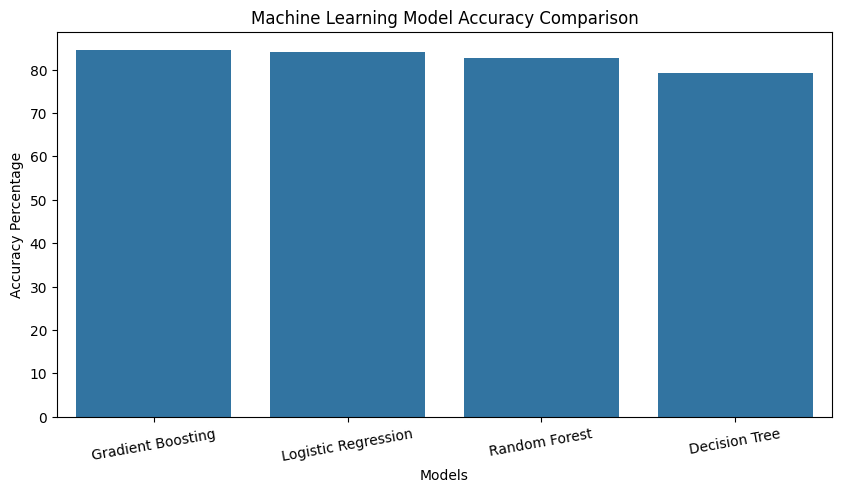

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Accuracy (%)',
    data=results
)

plt.title(
    'Machine Learning Model Accuracy Comparison'
)

plt.xlabel('Models')

plt.ylabel('Accuracy Percentage')

plt.xticks(rotation=10)

plt.show()

In [22]:
best_model = results.iloc[0]

print("Best Model Selected")

print(best_model)

Best Model Selected
Model           Gradient Boosting
Accuracy (%)                84.49
Name: 0, dtype: object


In [23]:
import joblib

joblib.dump(
    gb_model,
    r"C:\Users\abera\Downloads\best_gradient_boosting_model.pkl"
)

print("Best Gradient Boosting Model Saved Successfully")

Best Gradient Boosting Model Saved Successfully


In [24]:
import joblib

joblib.dump(
    lr_model,
    r"C:\Users\abera\Downloads\logistic_regression_model.pkl"
)

print("logistic_regression_model.pkl Saved")


joblib.dump(
    dt_model,
    r"C:\Users\abera\Downloads\decision_tree_model.pkl"
)

print("decision_tree_model.pkl Saved")


joblib.dump(
    rf_model,
    r"C:\Users\abera\Downloads\random_forest_model.pkl"
)

print("random_forest_model.pkl Saved")


joblib.dump(
    gb_model,
    r"C:\Users\abera\Downloads\gradient_boosting_model.pkl"
)

print("gradient_boosting_model.pkl Saved")


joblib.dump(
    scaler,
    r"C:\Users\abera\Downloads\scaler.pkl"
)

print("scaler.pkl Saved")


print("\nALL MODEL FILES CREATED SUCCESSFULLY")

logistic_regression_model.pkl Saved
decision_tree_model.pkl Saved
random_forest_model.pkl Saved
gradient_boosting_model.pkl Saved
scaler.pkl Saved

ALL MODEL FILES CREATED SUCCESSFULLY
